In [2]:
  ! wget https://www.lancaster.ac.uk/scc/sites/lora/lorasim-20170710.tgz
  ! tar -xvf lorasim-20170710.tgz

  !sudo apt-get install python2 && curl https://bootstrap.pypa.io/pip/2.7/get-pip.py -o get-pip.py && python2 get-pip.py && rm get-pip.py
  !sudo apt install python-tk
  !pip2 install -r 'lorasim/requirements.txt'


--2025-04-26 15:13:35--  https://www.lancaster.ac.uk/scc/sites/lora/lorasim-20170710.tgz
Resolving www.lancaster.ac.uk (www.lancaster.ac.uk)... 148.88.65.80, 2001:630:80:2ff::80:1
Connecting to www.lancaster.ac.uk (www.lancaster.ac.uk)|148.88.65.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 112640 (110K) [application/x-gzip]
Saving to: ‘lorasim-20170710.tgz’

lorasim-20170710.tg 100%[===================>] 110.00K   298KB/s    in 0.4s    

2025-04-26 15:13:36 (298 KB/s) - ‘lorasim-20170710.tgz’ saved [112640/112640]

lorasim/
lorasim/loraDir.py
lorasim/loraDirMulBS.py
lorasim/oneDirectionalLoraIntf.py
lorasim/requirements.txt
lorasim/directionalLoraIntf.py
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libpython2-stdlib libpython2.7-minimal libpython2.7-stdlib python2-minimal
  python2.7 python2.7-minimal
Suggested packages:
  python2-doc python-tk pyth

In [3]:
import os
import pandas as pd
import math

In [1]:
import subprocess

def simulate(n_nodes, tx_rate, exp, duration, base_stations, collision):
    env = os.environ.copy()
    env["MPLBACKEND"] = "Agg"

    # Use the base_stations parameter to specify the number of base stations
    result = subprocess.run(
        [
            "python2",
            "lorasim/loraDirMulBS.py",  # This script simulates multiple base stations
            str(n_nodes),          # Number of nodes
            str(tx_rate),          # Transmission rate
            str(exp),            # Experiment type
            str(duration),          # Simulation duration
            str(base_stations),       # Number of base stations
            str(collision),         # Collision rate
        ],
        env=env,
        capture_output=True,
        text=True,
    )

    # Print simulation information
    print(f"[SIM] Nodes={n_nodes}, BaseStations={base_stations}, EXP={exp}")
    print("[STDOUT]\n", result.stdout)
    print("[STDERR]\n", result.stderr)

# Der in aloha defined as S/G = e^(-2G)
def aloha_der(n_nodes,t):
    rate = 1e-6
    return math.exp(-2 * n_nodes * rate * t)


In [ ]:
duration = 24 * 3600 * 1000  # 1 day in ms
tx_rate = 1000000
print(type(tx_rate), tx_rate)
import glob

# Delete previously generated .dat files
for f in glob.glob("*.dat"):
    os.remove(f)
node_list = list(range(1, 10)) + list(range(10, 300, 10)) + list(range(300, 1700, 100))

for n_nodes in node_list:
    for base_stations in [1, 2, 3, 4, 8, 24]:  # Set different numbers of base stations
        simulate(n_nodes, tx_rate, 0, duration, base_stations, 1)



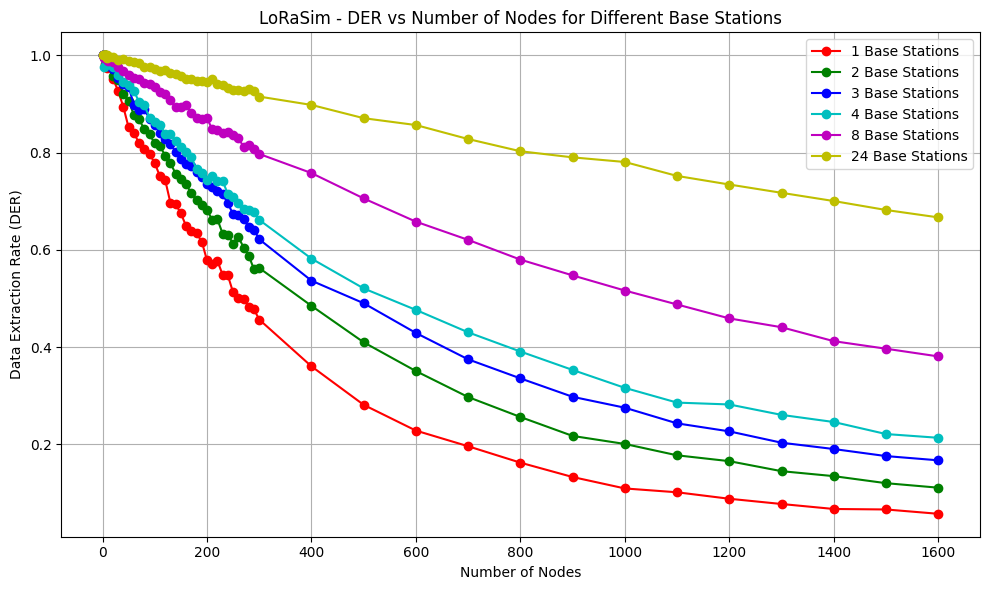

In [6]:
import matplotlib.pyplot as plt

base_stations_list = [1, 2, 3, 4, 8, 24]
colors = ['r', 'g', 'b', 'c', 'm', 'y']

plt.figure(figsize=(10, 6))

for i, bs in enumerate(base_stations_list):
    filename = f"exp0BS{bs}.dat"
    nodes = []
    ders = []
    try:
        with open(filename, 'r') as file:
            for line in file:
                parts = line.strip().split()
                if len(parts) != 2:
                    continue
                node, der = int(parts[0]), float(parts[1])
                nodes.append(node)
                ders.append(der)

        plt.plot(nodes, ders, label=f"{bs} Base Stations", color=colors[i % len(colors)], marker='o')
    except FileNotFoundError:
        print(f"File {filename} not found. Skipping...")

plt.xlabel("Number of Nodes")
plt.ylabel("Data Extraction Rate (DER)")
plt.title("LoRaSim - DER vs Number of Nodes for Different Base Stations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("der_vs_nodes.png")
plt.show()
